# Multi-Class Classification: Vehicle Types
This notebook trains a deep learning model to classify 6 types of vehicles:
- Bikes
- Cars
- Motorcycles
- Planes
- Ships
- Trains

## 1. Library imports

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from PIL import Image, ImageFilter
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

from skimage.feature import hog
import joblib




## 2. Visual analysis of the image dataset


=== Data structure ===
Classes found: ['Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
Number of classes: 6

Number of images per class:
  Class 'Bikes': 800 image files
  Class 'Cars': 790 image files
  Class 'Motorcycles': 800 image files
  Class 'Planes': 797 image files
  Class 'Ships': 800 image files
  Class 'Trains': 800 image files


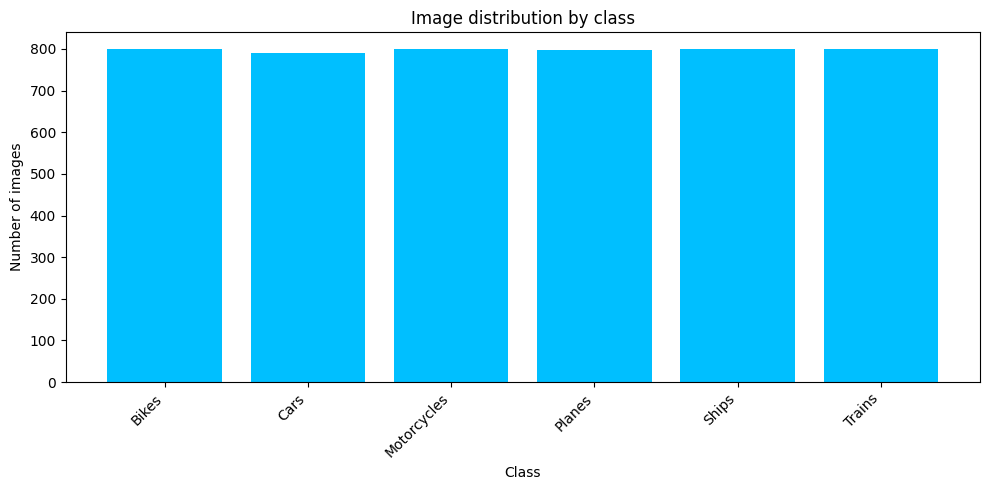


=== Example image for each class ===


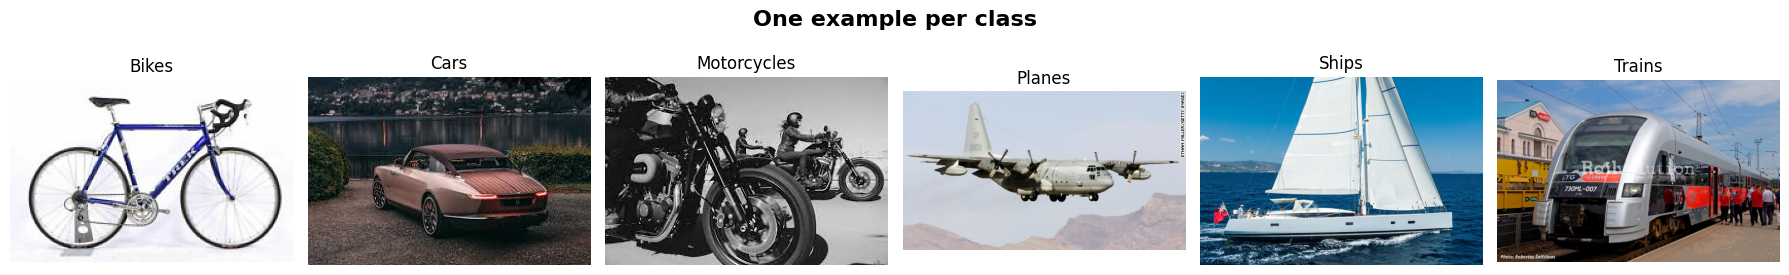

In [4]:
DATA_DIR = 'data'

print("\n=== Data structure ===")
if os.path.exists(DATA_DIR):
    classes = sorted([d for d in os.listdir(DATA_DIR)
                     if os.path.isdir(os.path.join(DATA_DIR, d))])
    print("Classes found: {}".format(classes))
    print("Number of classes: {}\n".format(len(classes)))

    images_per_class = []
    print("Number of images per class:")
    for class_name in classes:
        class_path = os.path.join(DATA_DIR, class_name)
        image_files = [f for f in os.listdir(class_path)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        num_images = len(image_files)
        images_per_class.append(num_images)
        print("  Class '{}': {} image files".format(class_name, num_images))

    # Barplot of number of images per class
    plt.figure(figsize=(10, 5))
    plt.bar(classes, images_per_class, color='deepskyblue')
    plt.ylabel('Number of images')
    plt.xlabel('Class')
    plt.title('Image distribution by class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Display one example per class (1 row grid)
    print("\n=== Example image for each class ===")
    n = len(classes)
    plt.figure(figsize=(3*n, 3))
    for i, class_name in enumerate(classes):
        class_path = os.path.join(DATA_DIR, class_name)
        image_files = [f for f in os.listdir(class_path)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            sample_file = random.choice(image_files)
            img_path = os.path.join(class_path, sample_file)
            img = Image.open(img_path)
            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.title(class_name, fontsize=12)
            plt.axis('off')
        else:
            plt.subplot(1, n, i+1)
            plt.text(0.5, 0.5, 'No image', ha='center', va='center', fontsize=10)
            plt.title(class_name)
            plt.axis('off')
    plt.suptitle('One example per class', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("The data folder does not exist.")

## 3. Configuration and data loading

In [7]:
def preprocess_images(data_dir, img_size=(128,128), blur=True, contrast=True):
    """
    Load images, preprocess (resize, normalization, filter, contrast).
    
    """
    X = []
    y = []
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

    for idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, fname)
                img = cv2.imread(img_path)
                img = cv2.resize(img, img_size)
                img = img / 255.0  # Normalization

                # Filtering (optional)
                if blur:
                    img = cv2.GaussianBlur(img, (3, 3), 0)
                
                # Contrast enhancement (optional)
                if contrast:
                    for i in range(3): # RGB
                        channel = (img[..., i] * 255).astype(np.uint8)
                        channel = cv2.equalizeHist(channel)
                        img[..., i] = channel / 255.0

                X.append(img)
                y.append(idx)
    X = np.array(X)
    y = np.array(y)
    return X, y, classes

X, y, classes = preprocess_images(DATA_DIR)

## 4. Feature extraction with HOG (Histogram of Oriented Gradients)

In [9]:
def hog_features_from_images(X, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2)):
    """
    Apply HOG to each image in X (X can be 4D: nb_img, h, w, c).
    Return a HOG feature matrix.
    """
    hog_features = []
    for img in X:
        # Convert to grayscale if image is RGB
        if img.ndim == 3 and img.shape[2] == 3:
            img_gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        else:
            img_gray = (img * 255).astype(np.uint8)
        # Calculate HOG descriptor
        features = hog(img_gray,
                       orientations=orientations,
                       pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block,
                       block_norm='L2-Hys',
                       transform_sqrt=True,
                       feature_vector=True)
        hog_features.append(features)
    return np.array(hog_features)
# HOG extraction
X_hog = hog_features_from_images(X)

## 5 split dataset

In [11]:


def split_dataset(X, y, test_size=0.2, random_state=42):
    """
    Split X et y en train/test.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_dataset(X_hog, y)


# 6. Analysis and evaluation of the SVM (Support Vector Machine) model

## 6.1 Model training

In [12]:
# SVM training
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## 6.2 Compute classification metrics: accuracy , precision , recall , F1 score.  

In [13]:
# Prediction on test set
y_pred = svm.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy: {:.4f}".format(acc))
print("Precision (macro): {:.4f}".format(prec))
print("Recall (macro): {:.4f}".format(rec))
print("F1 score (macro): {:.4f}".format(f1))

Accuracy: 0.7724
Precision (macro): 0.7733
Recall (macro): 0.7723
F1 score (macro): 0.7727


## 6.3 Confusion matrix

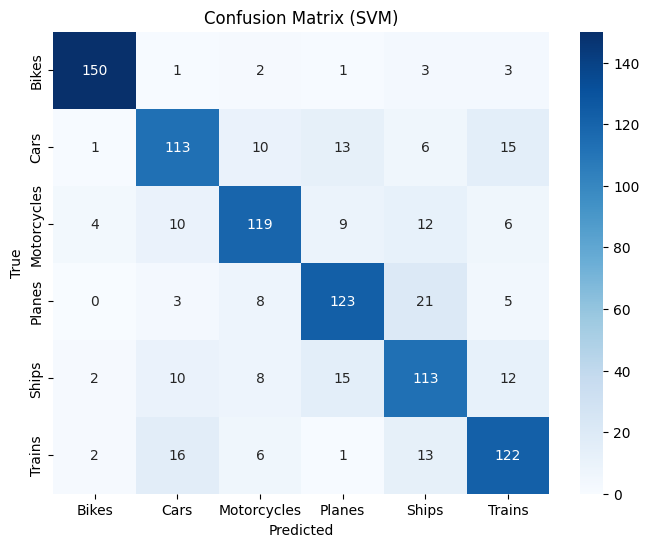

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 6.4 Save model

In [15]:
joblib.dump(svm, 'mon_modele_svm.joblib')


['mon_modele_svm.joblib']

# 7. Training and validation of the CNN (Convolutional Neural Network) model

## 7.1 Preparation of augmented images for CNN training and validation.

In [5]:
# Image generator for training with augmentation


IMG_SIZE = (128, 128) 
BATCH_SIZE = 32
DATA_DIR='data'

train_datagen = ImageDataGenerator(
    rescale=1./255,              # Pixel normalization
    validation_split=0.2,        # 20% for validation
    rotation_range=20,           # Random rotation
    width_shift_range=0.2,       # Horizontal shift
    height_shift_range=0.2,      # Vertical shift
    horizontal_flip=True,        # Horizontal flip
    zoom_range=0.2,              # Random zoom
    shear_range=0.15,            # Shear transformation
    fill_mode='nearest'          # Fill empty areas
)

# Generator for training images
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   
    subset='training',
    shuffle=True
)

# Generator for validation images
validation_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   
    subset='validation',
    shuffle=True
)
# Save class names for later
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

Found 3830 images belonging to 6 classes.
Found 957 images belonging to 6 classes.


## 7.2. CNN model construction

In [6]:
model = keras.Sequential([
    # First convolution block
    layers.Conv2D(32, (3, 3), activation='relu', 
                  input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Second block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Third block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Fourth block
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Fifth block (added to better handle 6 classes)
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    # CHANGED: Output with NUM_CLASSES neurons + softmax
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# CHANGED: Loss function for multi-class
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # For multi-class
    metrics=['accuracy']
)

## 7.3. CNN model training

In [18]:
# Callbacks
EPOCHS = 20  

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    'best_vehicle_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("\n=== Training start ===")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)


=== Training start ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.2495 - loss: 2.2681
Epoch 1: val_accuracy improved from None to 0.16614, saving model to best_vehicle_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 117s 944ms/step - accuracy: 0.3274 - loss: 1.9238 - val_accuracy: 0.1661 - val_loss: 2.1222 - learning_rate: 0.0010
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.4551 - loss: 1.4379
Epoch 2: val_accuracy improved from 0.16614 to 0.21421, saving model to best_vehicle_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 99s 821ms/step - accuracy: 0.4862 - loss: 1.3729 - val_accuracy: 0.2142 - val_loss: 2.4498 - learning_rate: 0.0010
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.5485 - loss: 1.2230
Epoch 3: val_accuracy did not improve from 0.21421
120/120 ━━━━━━━━━━━━━━━━━━━━ 92s 770ms/step - accuracy: 0.5666 - loss: 1.1830 - val_accuracy: 0.1902 - val_loss: 2.1601 - learning_rate: 0.0010
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━

## 7.4. Training results visualization

In [10]:
y_true = []
y_pred = []


for i in range(len(validation_generator)):
    X_batch, y_batch = validation_generator[i]
    preds = model.predict(X_batch, verbose=0)
    y_pred_batch = np.argmax(preds, axis=1)
    y_true_batch = np.argmax(y_batch, axis=1)
    y_true.extend(y_true_batch)
    y_pred.extend(y_pred_batch)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


acc = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average='macro')
rec_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

print("==== Global scores ====")
print("Accuracy  : {:.4f}".format(acc))
print("Precision : {:.4f}".format(prec_macro))
print("Recall    : {:.4f}".format(rec_macro))
print("F1-score  : {:.4f}".format(f1_macro))

==== Global scores ====
Accuracy  : 0.8245
Precision : 0.8389
Recall    : 0.8246
F1-score  : 0.8220


## 7.5 Confusion matrix

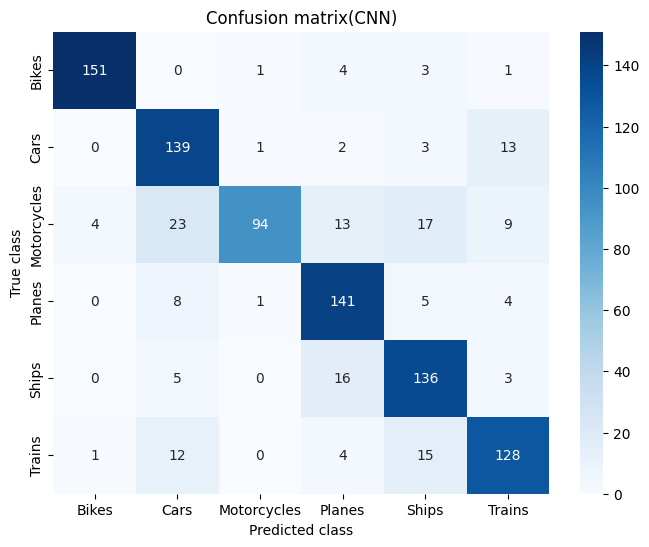

In [11]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion matrix(CNN)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.show()

## 7.6 Model saving

In [21]:
# Save final model
model.save('vehicle_classifier_model.keras')
print("\n✓ Model saved as 'vehicle_classifier_model.keras'")


✓ Model saved as 'vehicle_classifier_model.keras'


## 8. Load model for prediction

### I only exported the CNN model because its F1 score is higher than SVM's.

In [9]:
model = keras.models.load_model('vehicle_classifier_model.keras')



## 9 Prediction function with visualization

In [27]:
def predict_vehicle(image_path, model, threshold=0.5):
    """
    Predicts the type of vehicle in an image.
    Args:
        image_path: Path to the image
        model: Trained model
        threshold: confidence threshold (between 0 and 1, default 0.5 = 50%)
    """
    img = Image.open(image_path)
    img_resized = img.resize((128, 128))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class_idx = np.argmax(predictions)
    predicted_class = CLASS_NAMES[predicted_class_idx]
    confidence = predictions[predicted_class_idx] * 100

    # Threshold verification
    is_ood = confidence < (threshold * 100)

    # Display
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    if is_ood:
        plt.title('Prediction: Unknown/Out-of-domain\nConfidence: {:.2f}%'.format(confidence), 
                  fontsize=14, fontweight='bold', color='red')
    else:
        plt.title('Prediction: {}\nConfidence: {:.2f}%'.format(predicted_class, confidence), 
                  fontsize=14, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # MODIFICATION ICI: Si c'est OOD, toutes les barres sont grises
    if is_ood:
        colors = ['gray' for i in range(len(CLASS_NAMES))]
    else:
        colors = ['green' if i == predicted_class_idx else 'gray' for i in range(len(CLASS_NAMES))]
    
    plt.barh(CLASS_NAMES, predictions * 100, color=colors)
    plt.xlabel('Probability (%)')
    plt.title('Probabilities per class', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

    
    print("\n=== Prediction result ===")
    if is_ood:
        print("Predicted class: Unknown/Out-of-domain!")
    else:
        print("Predicted class: {}".format(predicted_class))
        print("Confidence: {:.2f}%".format(confidence))
    print("Probabilities for all classes:")
    for name, prob in zip(CLASS_NAMES, predictions):
        print("  {:12s}: {:6.2f}%".format(name, prob*100))
    
    if is_ood:
        return None, confidence, predictions
    else:
        return predicted_class, confidence, predictions

print("✓ Prediction function defined!")

✓ Prediction function defined!


## 10. Test on multiple images


Image: 1.jpg


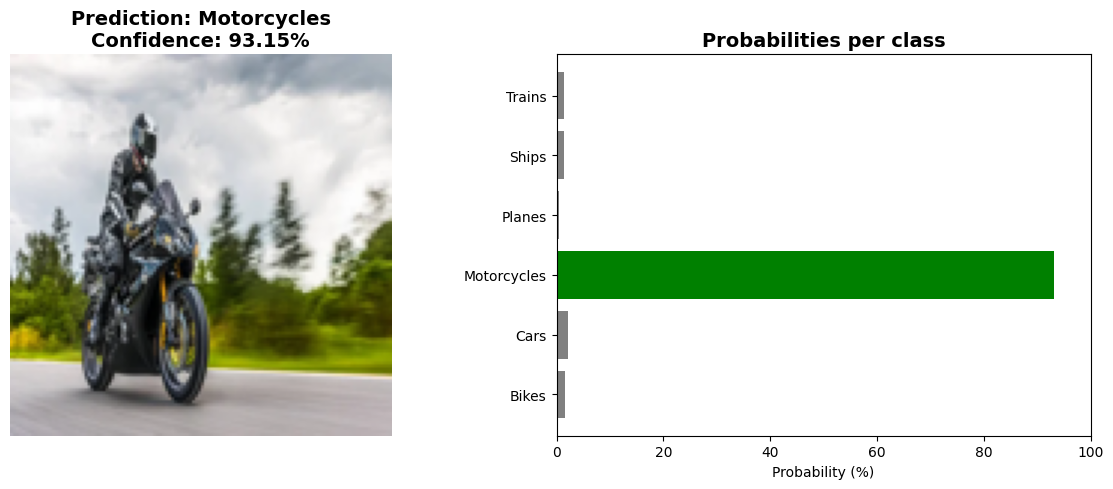


=== Prediction result ===
Predicted class: Motorcycles
Confidence: 93.15%
Probabilities for all classes:
  Bikes       :   1.52%
  Cars        :   2.15%
  Motorcycles :  93.15%
  Planes      :   0.38%
  Ships       :   1.33%
  Trains      :   1.47%

Image: 2.jpg


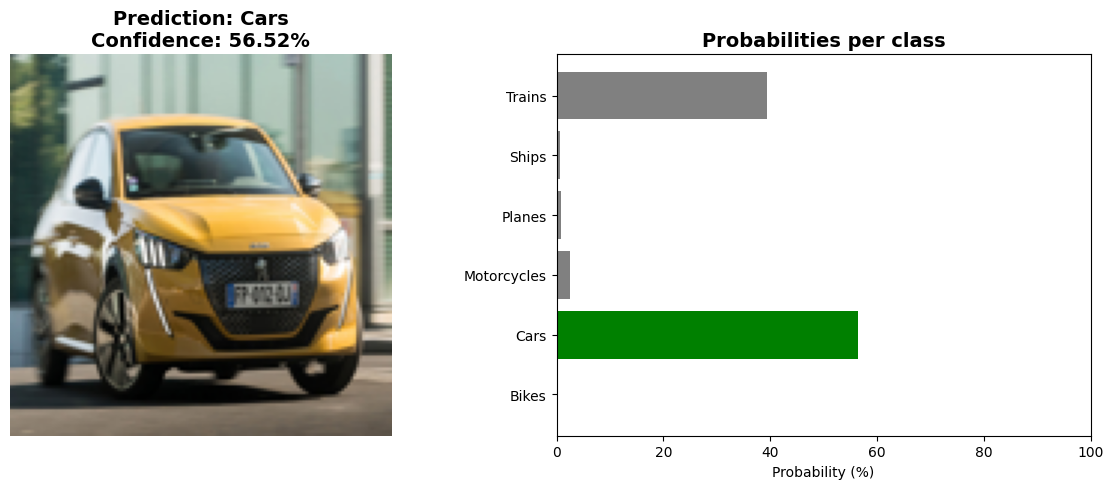


=== Prediction result ===
Predicted class: Cars
Confidence: 56.52%
Probabilities for all classes:
  Bikes       :   0.04%
  Cars        :  56.52%
  Motorcycles :   2.61%
  Planes      :   0.83%
  Ships       :   0.66%
  Trains      :  39.34%

Image: 11.jpg


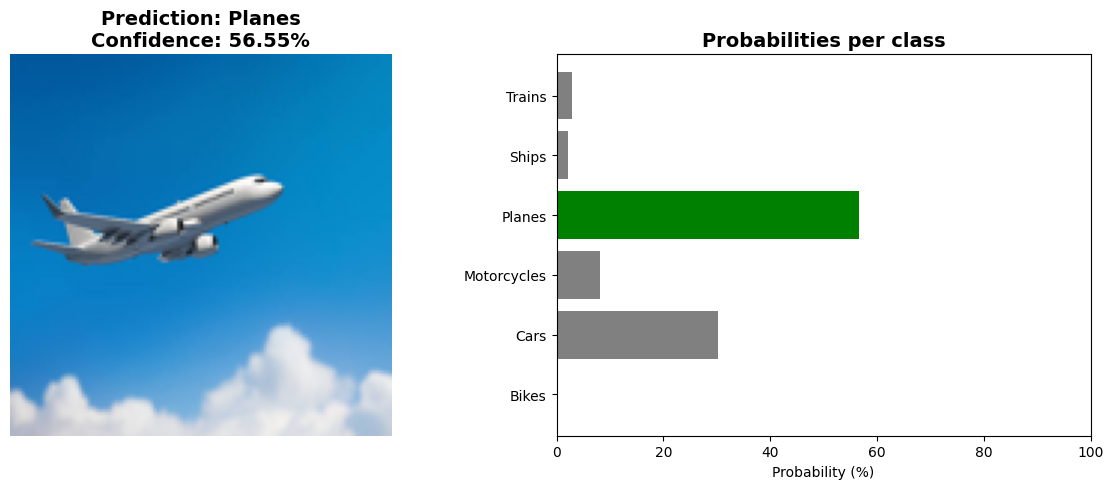


=== Prediction result ===
Predicted class: Planes
Confidence: 56.55%
Probabilities for all classes:
  Bikes       :   0.16%
  Cars        :  30.25%
  Motorcycles :   8.08%
  Planes      :  56.55%
  Ships       :   2.14%
  Trains      :   2.82%

Image: 4.jpg


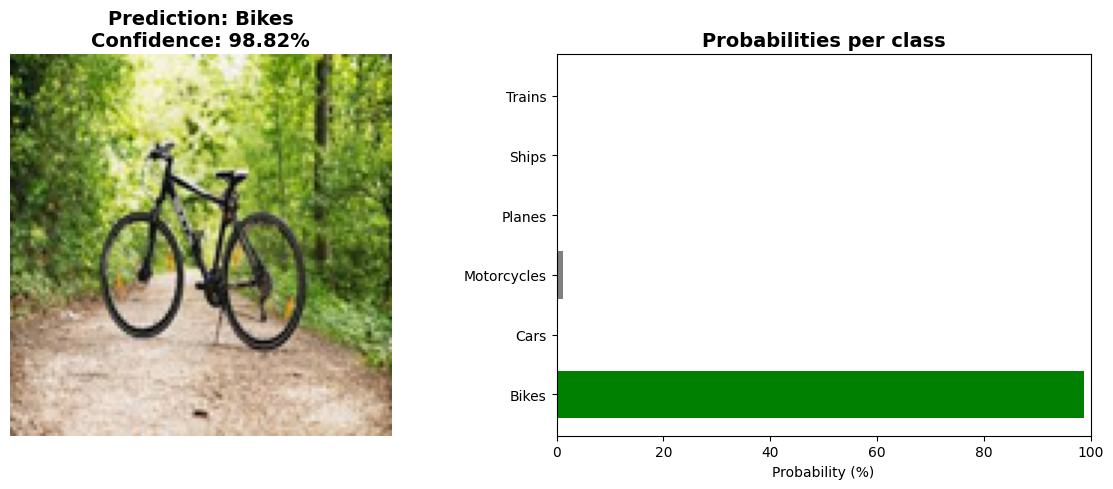


=== Prediction result ===
Predicted class: Bikes
Confidence: 98.82%
Probabilities for all classes:
  Bikes       :  98.82%
  Cars        :   0.00%
  Motorcycles :   1.18%
  Planes      :   0.00%
  Ships       :   0.00%
  Trains      :   0.00%

Image: 5.jpg


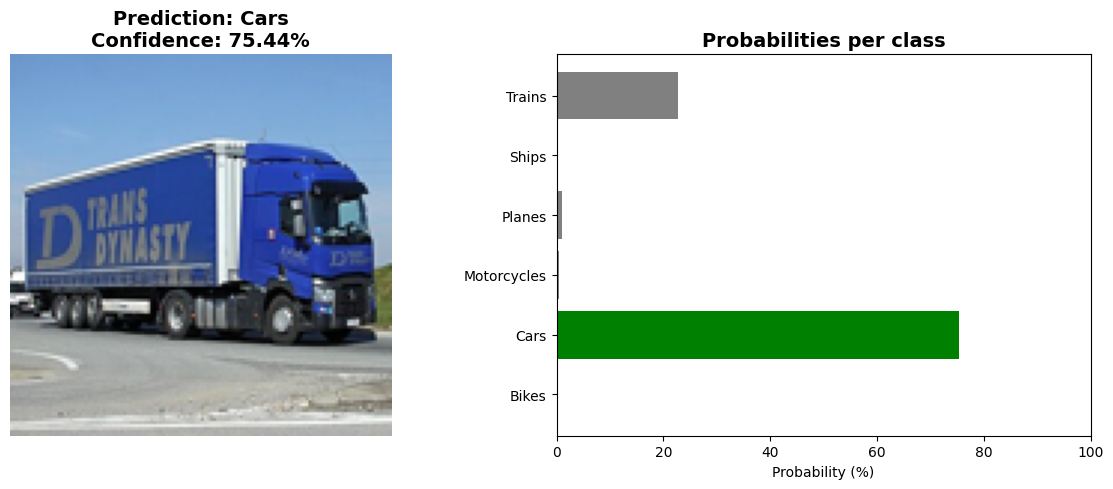


=== Prediction result ===
Predicted class: Cars
Confidence: 75.44%
Probabilities for all classes:
  Bikes       :   0.00%
  Cars        :  75.44%
  Motorcycles :   0.54%
  Planes      :   1.07%
  Ships       :   0.13%
  Trains      :  22.82%

Image: 6.jpg


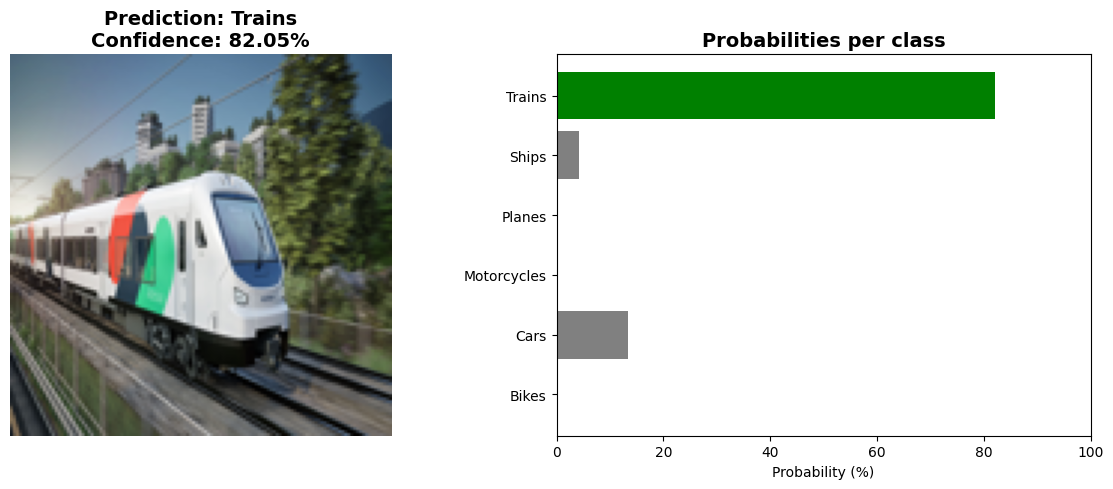


=== Prediction result ===
Predicted class: Trains
Confidence: 82.05%
Probabilities for all classes:
  Bikes       :   0.00%
  Cars        :  13.31%
  Motorcycles :   0.20%
  Planes      :   0.20%
  Ships       :   4.23%
  Trains      :  82.05%

Image: 7.jpg


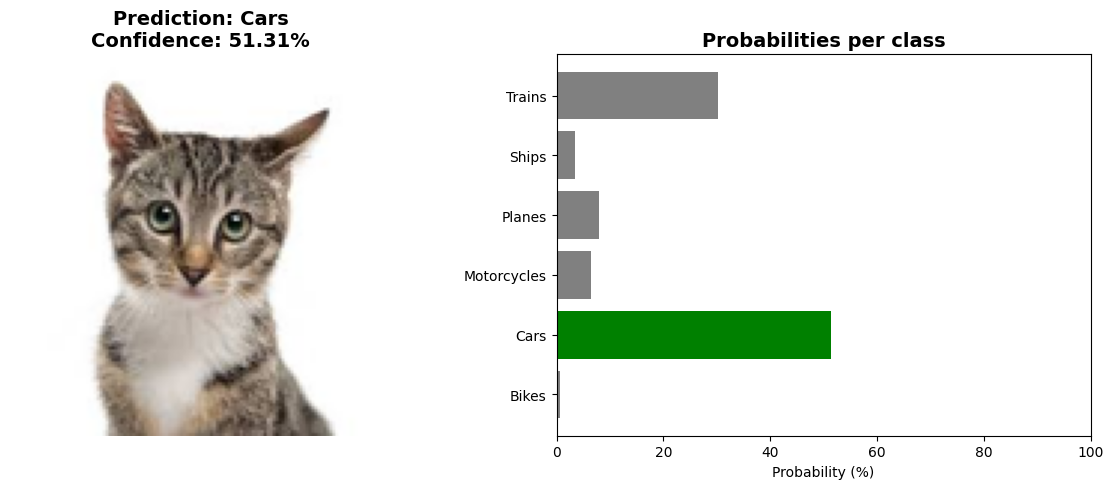


=== Prediction result ===
Predicted class: Cars
Confidence: 51.31%
Probabilities for all classes:
  Bikes       :   0.60%
  Cars        :  51.31%
  Motorcycles :   6.54%
  Planes      :   7.89%
  Ships       :   3.40%
  Trains      :  30.26%

Image: 8.jpg


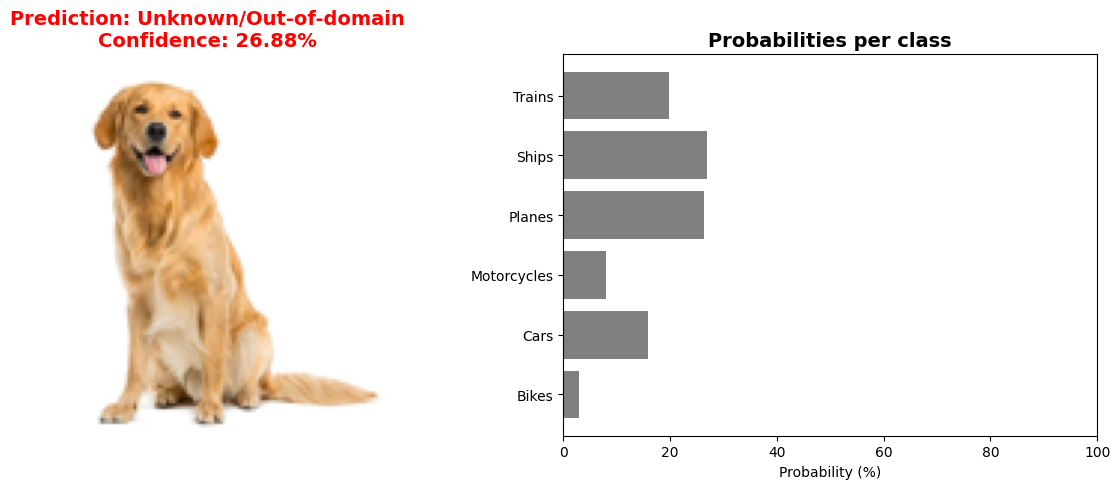


=== Prediction result ===
Predicted class: Unknown/Out-of-domain!
Probabilities for all classes:
  Bikes       :   2.97%
  Cars        :  15.96%
  Motorcycles :   8.05%
  Planes      :  26.33%
  Ships       :  26.88%
  Trains      :  19.81%

Image: 9.jpg


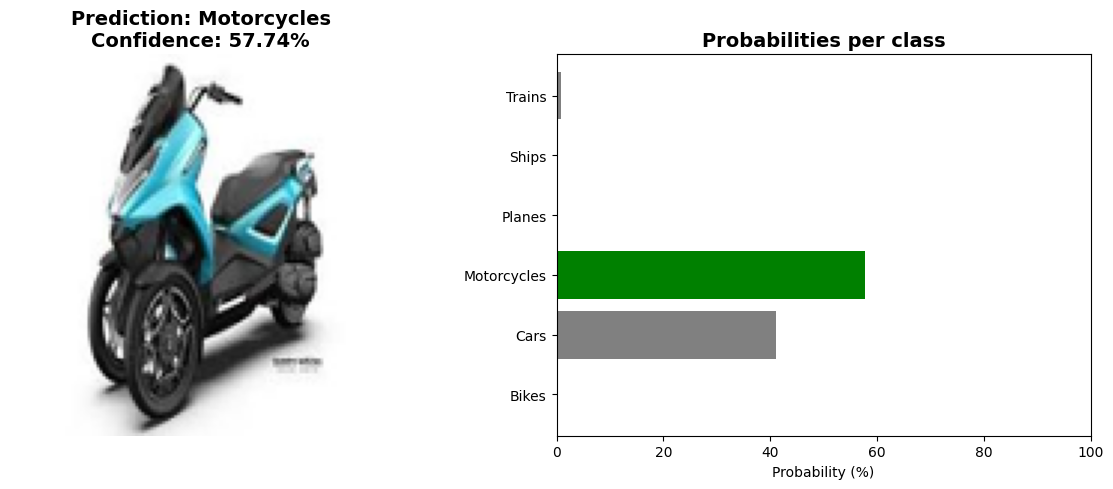


=== Prediction result ===
Predicted class: Motorcycles
Confidence: 57.74%
Probabilities for all classes:
  Bikes       :   0.01%
  Cars        :  41.18%
  Motorcycles :  57.74%
  Planes      :   0.14%
  Ships       :   0.02%
  Trains      :   0.91%

PREDICTION SUMMARY
1.jpg                → Motorcycles  (93.15%)
2.jpg                → Cars         (56.52%)
11.jpg               → Planes       (56.55%)
4.jpg                → Bikes        (98.82%)
5.jpg                → Cars         (75.44%)
6.jpg                → Trains       (82.05%)
7.jpg                → Cars         (51.31%)
8.jpg                → Unknown      (26.88%)
9.jpg                → Motorcycles  (57.74%)


In [28]:
def test_multiple_vehicles(image_paths, model):
    """
    Tests the model on multiple images.
    """
    results = []
    
    for img_path in image_paths:
        if os.path.exists(img_path):
            print("\n{}".format('='*50))
            print("Image: {}".format(img_path))
            print('='*50)
            
            predicted_class, confidence, probs = predict_vehicle(
                img_path, model
            )
            
            results.append({
                'image': img_path,
                'prediction': predicted_class,
                'confidence': confidence,
                'probabilities': probs
            })
        else:
            print("\n⚠ Image not found: {}".format(img_path))
    
    return results

# Example with multiple images
test_images = [
    '1.jpg',
    '2.jpg',
    '11.jpg',
    '4.jpg',
    '5.jpg',
    '6.jpg',
    '7.jpg',
    '8.jpg',
    '9.jpg'
]


results = test_multiple_vehicles(test_images, model)

print("\n{}".format("="*60))
print("PREDICTION SUMMARY")
print("{}".format("="*60))
for r in results:
    
    pred = r['prediction'] if r['prediction'] is not None else "Unknown"
    conf = "{:.2f}%".format(r['confidence']) if r['confidence'] is not None else "N/A"
    print("{:20s} → {:12s} ({})".format(r['image'], pred, conf))